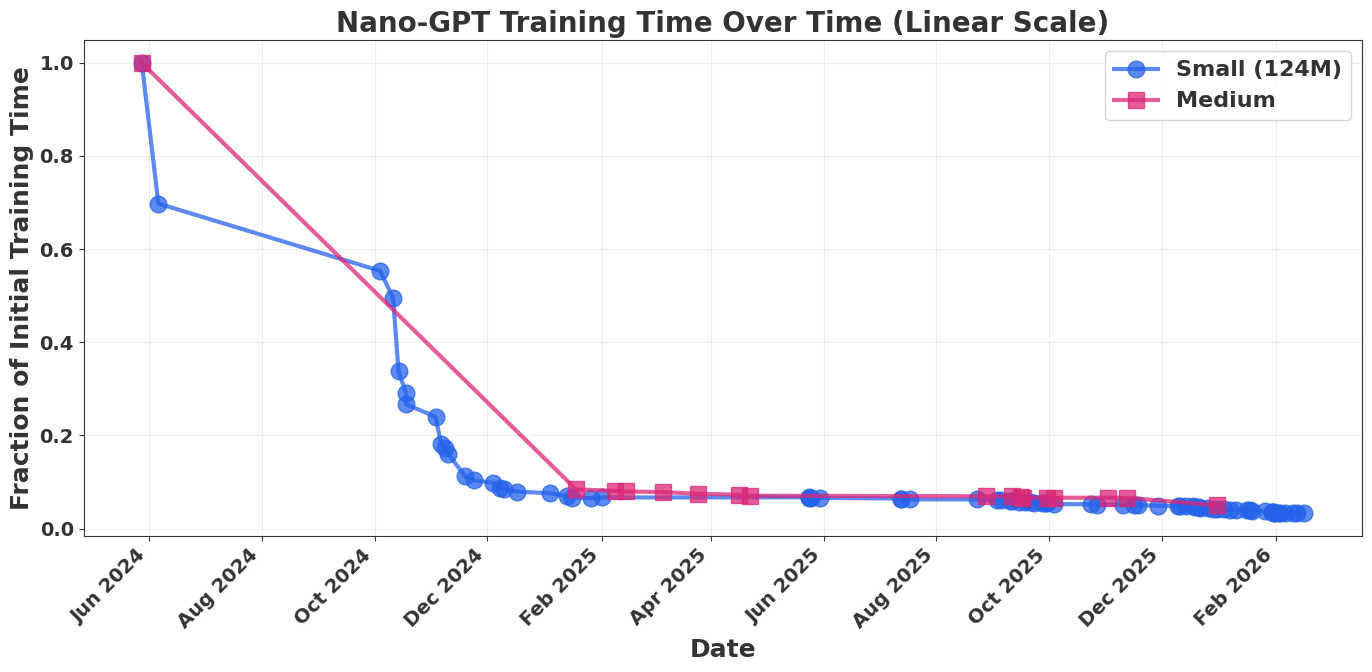

In [247]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

os.makedirs("figures", exist_ok=True)

# Epoch-like vibe: clean white background, larger elements, minimalist
plt.rcParams.update({
    "font.size": 16,
    "font.weight": "bold",
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "text.color": "#333333",
})

cols = ["record", "time_str", "description", "date_str", "log", "contributors"]

df_small = pd.read_csv("nano_small_run.csv", header=None, names=cols)
df_medium = pd.read_csv("nano_medium_run.csv", skiprows=1, header=None, names=cols)

def parse_minutes(s):
    s = s.strip().rstrip("*")
    val = float(s.split()[0])
    if "hour" in s:
        val *= 60
    return val

for df in [df_small, df_medium]:
    df["minutes"] = df["time_str"].apply(parse_minutes)
    df["date"] = pd.to_datetime(df["date_str"], format="%m/%d/%y", errors="coerce")
    df.dropna(subset=["date"], inplace=True)
    df["frac"] = df["minutes"] / df["minutes"].iloc[0]

fig1, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(df_small["date"], df_small["frac"], marker="o", markersize=12, linewidth=3, color="#2563eb", alpha=0.75, label="Small (124M)")
ax1.plot(df_medium["date"], df_medium["frac"], marker="s", markersize=12, linewidth=3, color="#db2777", alpha=0.75, label="Medium")
ax1.set_xlabel("Date", fontweight=800)
ax1.set_ylabel("Fraction of Initial Training Time", fontweight=800)
ax1.set_title("Nano-GPT Training Time Over Time (Linear Scale)", fontweight=800)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight(800)
ax1.legend(loc="upper right", prop={"weight": 800, "size": 16})
ax1.grid(True, alpha=0.3, color="#cccccc")
fig1.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig("figures/training_time_linear.png", dpi=150, bbox_inches="tight")
plt.show()


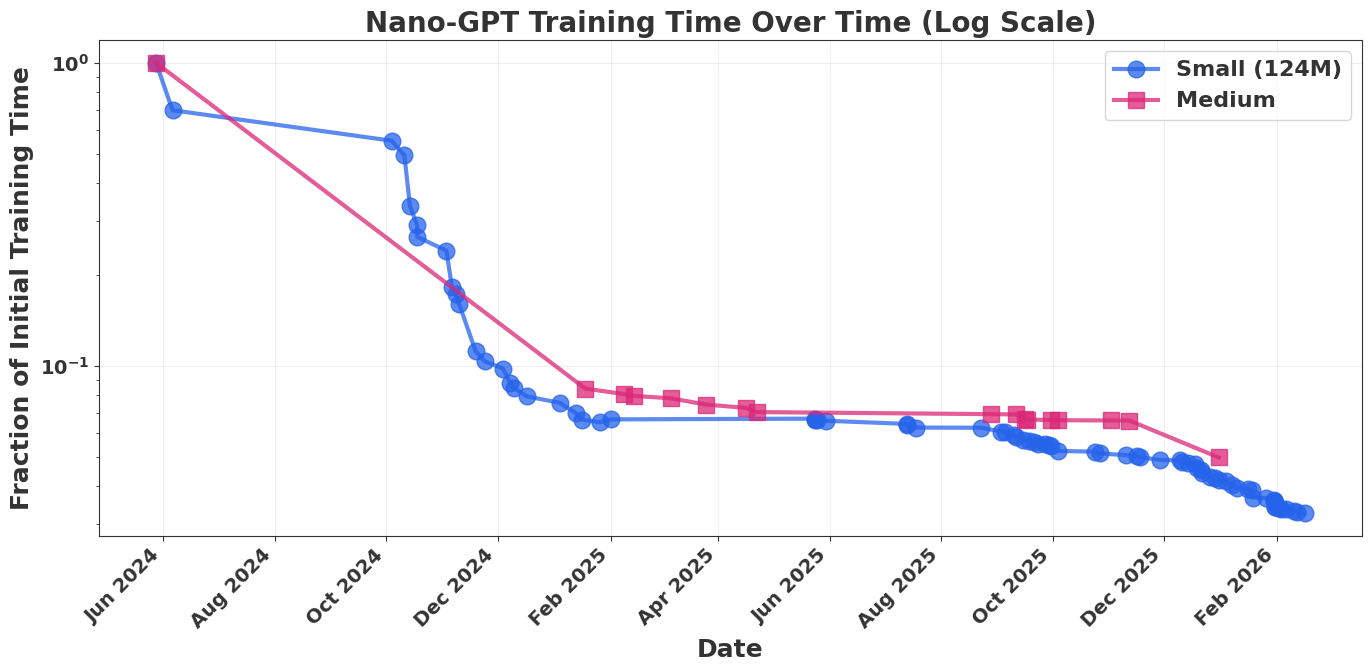

In [248]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_small["date"], df_small["frac"], marker="o", markersize=12, linewidth=3, color="#2563eb", alpha=0.75, label="Small (124M)")
ax.plot(df_medium["date"], df_medium["frac"], marker="s", markersize=12, linewidth=3, color="#db2777", alpha=0.75, label="Medium")
ax.set_xlabel("Date", fontweight=800)
ax.set_ylabel("Fraction of Initial Training Time", fontweight=800)
ax.set_title("Nano-GPT Training Time Over Time (Log Scale)", fontweight=800)
ax.set_yscale("log")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight(800)
ax.legend(loc="upper right", prop={"weight": 800, "size": 16})
ax.grid(True, alpha=0.3, color="#cccccc")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig("figures/training_time_log.png", dpi=150, bbox_inches="tight")
plt.show()

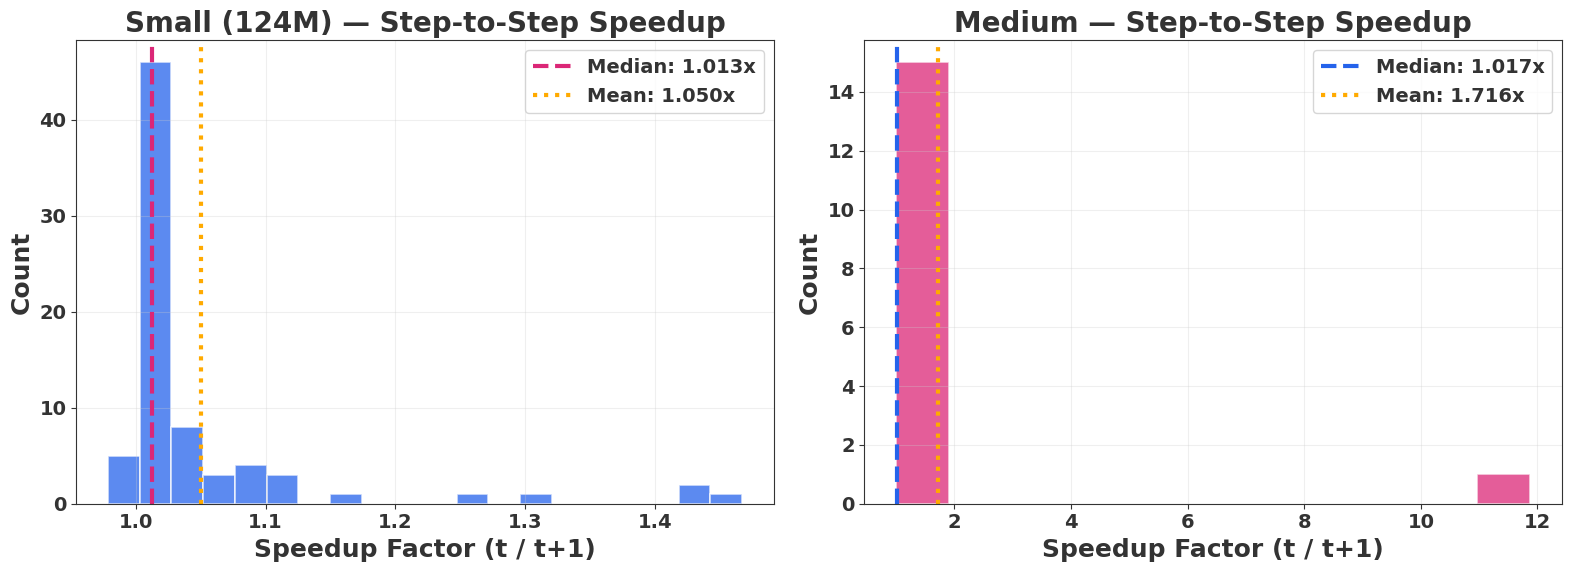

Small (124M)  — min: 0.979x, max: 1.467x, mean: 1.050x, median: 1.013x
Medium (350M) — min: 1.000x, max: 11.877x, mean: 1.716x, median: 1.017x


In [249]:
speedup_small = df_small["minutes"].values[:-1] / df_small["minutes"].values[1:]
speedup_medium = df_medium["minutes"].values[:-1] / df_medium["minutes"].values[1:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(speedup_small, bins=20, color="#2563eb", alpha=0.75, edgecolor="white", linewidth=1.2)
ax1.axvline(np.median(speedup_small), color="#db2777", linewidth=3, linestyle="--", label=f"Median: {np.median(speedup_small):.3f}x")
ax1.axvline(np.mean(speedup_small), color="#ffaa00", linewidth=3, linestyle=":", label=f"Mean: {np.mean(speedup_small):.3f}x")
ax1.set_xlabel("Speedup Factor (t / t+1)", fontweight=800)
ax1.set_ylabel("Count", fontweight=800)
ax1.set_title("Small (124M) — Step-to-Step Speedup", fontweight=800)
ax1.legend(prop={"weight": 800, "size": 14})
ax1.grid(True, alpha=0.3, color="#cccccc")
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight(800)

ax2.hist(speedup_medium, bins=12, color="#db2777", alpha=0.75, edgecolor="white", linewidth=1.2)
ax2.axvline(np.median(speedup_medium), color="#2563eb", linewidth=3, linestyle="--", label=f"Median: {np.median(speedup_medium):.3f}x")
ax2.axvline(np.mean(speedup_medium), color="#ffaa00", linewidth=3, linestyle=":", label=f"Mean: {np.mean(speedup_medium):.3f}x")
ax2.set_xlabel("Speedup Factor (t / t+1)", fontweight=800)
ax2.set_ylabel("Count", fontweight=800)
ax2.set_title("Medium — Step-to-Step Speedup", fontweight=800)
ax2.legend(prop={"weight": 800, "size": 14})
ax2.grid(True, alpha=0.3, color="#cccccc")
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontweight(800)

plt.tight_layout()
plt.savefig("figures/speedup_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Small (124M)  — min: {speedup_small.min():.3f}x, max: {speedup_small.max():.3f}x, "
      f"mean: {speedup_small.mean():.3f}x, median: {np.median(speedup_small):.3f}x")
print(f"Medium (350M) — min: {speedup_medium.min():.3f}x, max: {speedup_medium.max():.3f}x, "
      f"mean: {speedup_medium.mean():.3f}x, median: {np.median(speedup_medium):.3f}x")

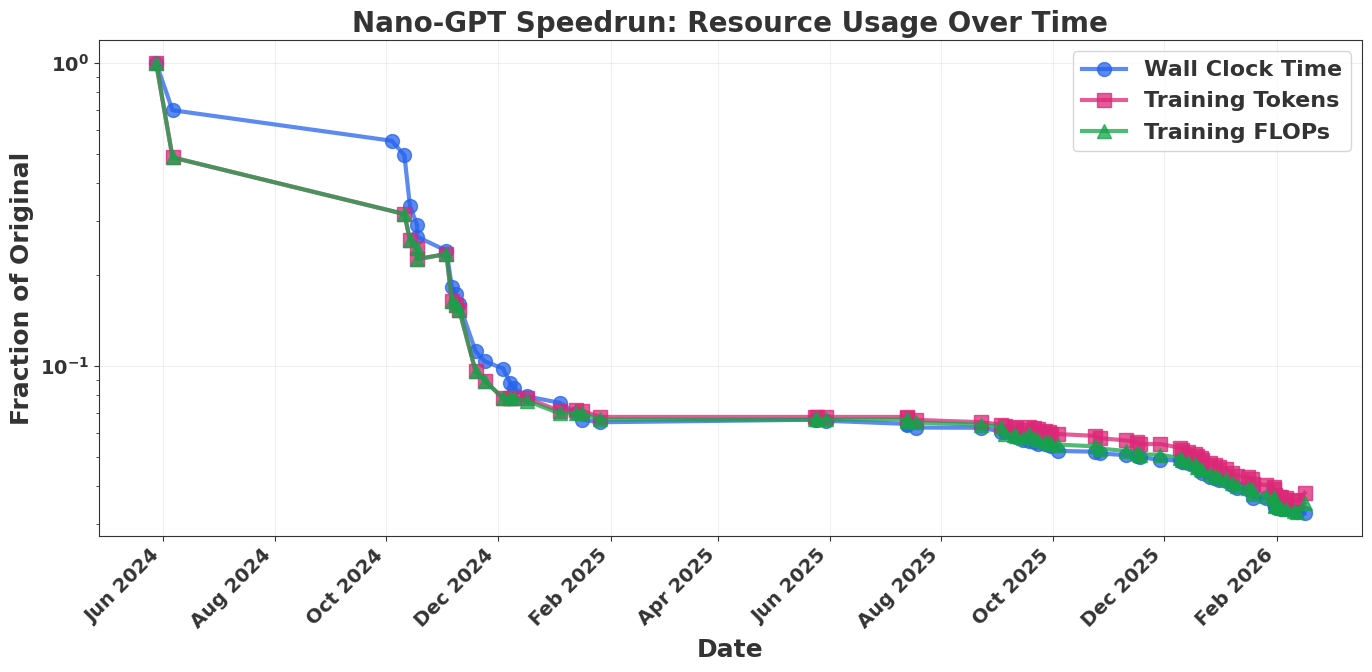

In [250]:
df_records = pd.read_csv("nanogpt_speedrun_records.csv")
df_records["date"] = pd.to_datetime(df_records["date"])
df_records["flop_frac"] = df_records["training_flops"] / df_records["training_flops"].iloc[0]
df_records["token_frac"] = df_records["training_tokens_M"] / df_records["training_tokens_M"].iloc[0]
df_records["time_frac"] = df_records["record_time_min"] / df_records["record_time_min"].iloc[0]

df_tokens = df_records.dropna(subset=["training_tokens_M"])
df_flops  = df_records.dropna(subset=["training_flops"])

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_records["date"], df_records["time_frac"], marker="o", markersize=10, linewidth=3, color="#2563eb", alpha=0.75, label="Wall Clock Time")
ax.plot(df_tokens["date"], df_tokens["token_frac"], marker="s", markersize=10, linewidth=3, color="#db2777", alpha=0.75, label="Training Tokens")
ax.plot(df_flops["date"],  df_flops["flop_frac"],   marker="^", markersize=10, linewidth=3, color="#16a34a", alpha=0.75, label="Training FLOPs")
ax.set_xlabel("Date", fontweight=800)
ax.set_ylabel("Fraction of Original", fontweight=800)
ax.set_title("Nano-GPT Speedrun: Resource Usage Over Time", fontweight=800)
ax.set_yscale("log")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight(800)
ax.legend(prop={"weight": 800, "size": 16})
ax.grid(True, alpha=0.3, color="#cccccc")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig("figures/resource_usage_small.png", dpi=150, bbox_inches="tight")
plt.show()

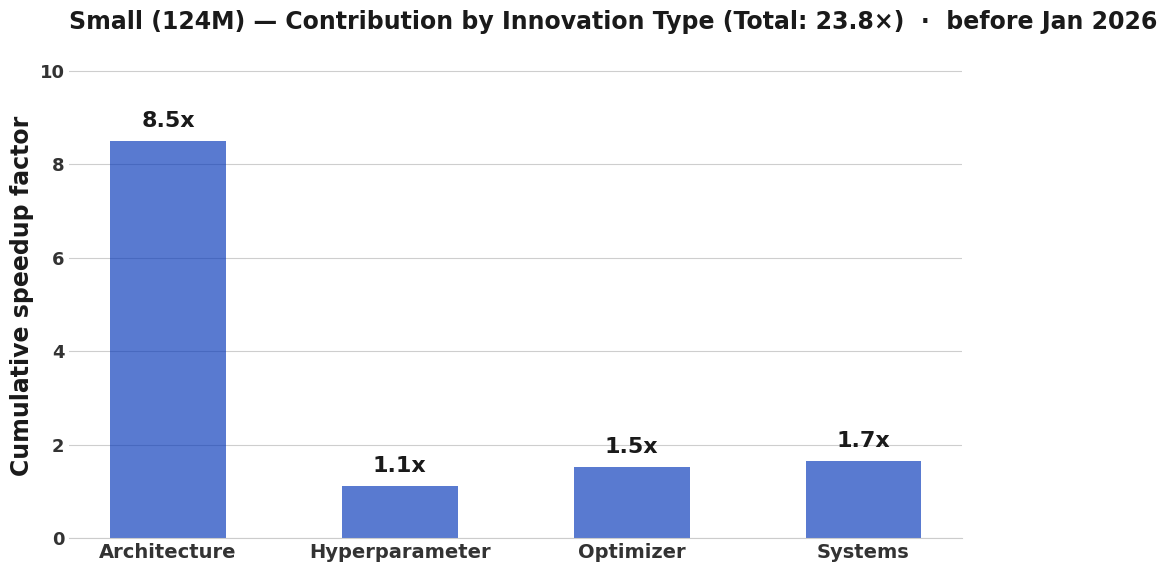


Total wall clock speedup: 23.76x  (45.0 min → 1.894 min)
  Architecture        : 8.49x  (26 records)
  Hyperparameter      : 1.11x  (3 records)
  Optimizer           : 1.52x  (10 records)
  Systems             : 1.65x  (16 records)


In [251]:
# Filter by date: set cutoff_date to limit analysis (None = no filter)
cutoff_date = pd.Timestamp("2026-01-01")
df_analysis = df_records[df_records["date"] < cutoff_date] if cutoff_date is not None else df_records

times = df_analysis["record_time_min"].values
labels = df_analysis["innovation_label"].values

step_speedups = times[:-1] / times[1:]
step_labels = labels[1:]

categories = sorted(pd.unique(step_labels))
colors = ["#2563eb", "#16a34a", "#db2777", "#f59e0b", "#8b5cf6"]
colors = [colors[i % len(colors)] for i in range(len(categories))]

category_total_speedup = {}
for cat in categories:
    mask = step_labels == cat
    category_total_speedup[cat] = np.prod(step_speedups[mask])

total_speedup = np.prod(step_speedups)

bar_heights = [category_total_speedup[c] for c in categories]

fig, ax = plt.subplots(figsize=(10, 6))
# color="#8eb4eb"  # previous color (light cornflower blue)
bars = ax.bar(categories, bar_heights, color="#0033B8", alpha=0.65, edgecolor="none", width=0.5)

ax.set_ylim(0, max(bar_heights) * 1.22)
for bar, cat in zip(bars, categories):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(bar_heights) * 0.025,
            f"{category_total_speedup[cat]:.1f}x",
            ha="center", va="bottom", fontweight=800, fontsize=16, color="#1a1a1a")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

ax.tick_params(axis="x", length=0, labelsize=14)
ax.tick_params(axis="y", length=0, labelsize=13)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight(800)

ax.set_ylabel("Cumulative speedup factor", fontsize=17, fontweight=800, color="#1a1a1a")
ax.grid(True, axis="y", alpha=0.95, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

title = f"Small (124M) — Contribution by Innovation Type (Total: {total_speedup:.1f}×)"
if cutoff_date is not None:
    title += f"  ·  before {cutoff_date.strftime('%b %Y')}"
ax.set_title(title, fontsize=17, fontweight=800, color="#1a1a1a", loc="left", pad=18)
plt.tight_layout()
plt.savefig("figures/cumulative_speedup_small.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal wall clock speedup: {total_speedup:.2f}x  ({times[0]:.1f} min → {times[-1]:.3f} min)")
for cat in categories:
    n = np.sum(step_labels == cat)
    print(f"  {cat:20s}: {category_total_speedup[cat]:.2f}x  ({n} records)")

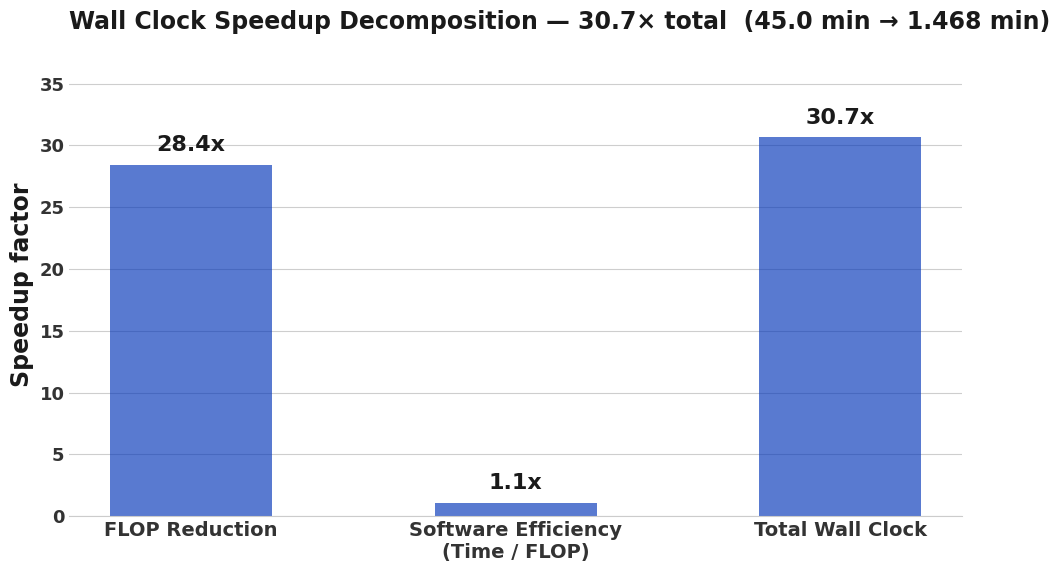

FLOP reduction factor  : 28.44x  (7.60e+18 → 2.67e+17)
Software efficiency    : 1.08x  (wall clock improved 1.08x more than FLOPs alone)
Total wall clock       : 30.65x


In [252]:
# Decompose total wall clock speedup into:
#   FLOP reduction factor  = flops_initial / flops_final
#   Software factor        = total_wall_clock_speedup / flop_factor
#                          (captures kernel efficiency, better hardware utilization, etc.)
#   Total wall clock       = flop_factor × software_factor

flop_factor  = df_records["training_flops"].iloc[0] / df_records["training_flops"].iloc[-1]
total_factor = df_records["record_time_min"].iloc[0] / df_records["record_time_min"].iloc[-1]
software_factor = total_factor / flop_factor

bar_labels = ["FLOP Reduction", "Software Efficiency\n(Time / FLOP)", "Total Wall Clock"]
bar_values = [flop_factor, software_factor, total_factor]

fig, ax = plt.subplots(figsize=(10, 6))
# color="#8eb4eb"  # previous color (light cornflower blue) ="#0033B8"
bars = ax.bar(bar_labels, bar_values, color="#0033B8", alpha=0.65, edgecolor="none", width=0.5)

ax.set_ylim(0, max(bar_values) * 1.22)
for bar, val in zip(bars, bar_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(bar_values) * 0.025,
            f"{val:.1f}x", ha="center", va="bottom", fontweight=800, fontsize=16, color="#1a1a1a")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

ax.tick_params(axis="x", length=0, labelsize=14)
ax.tick_params(axis="y", length=0, labelsize=13)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight(800)

ax.set_ylabel("Speedup factor", fontsize=17, fontweight=800, color="#1a1a1a")
ax.grid(True, axis="y", alpha=0.95, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

ax.set_title(
    f"Wall Clock Speedup Decomposition — {total_factor:.1f}× total  "
    f"({df_records['record_time_min'].iloc[0]:.1f} min → {df_records['record_time_min'].iloc[-1]:.3f} min)",
    fontsize=17, fontweight=800, color="#1a1a1a", loc="left", pad=18
)
plt.tight_layout()
plt.savefig("figures/speedup_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"FLOP reduction factor  : {flop_factor:.2f}x  ({df_records['training_flops'].iloc[0]:.2e} → {df_records['training_flops'].iloc[-1]:.2e})")
print(f"Software efficiency    : {software_factor:.2f}x  (wall clock improved {software_factor:.2f}x more than FLOPs alone)")
print(f"Total wall clock       : {total_factor:.2f}x")

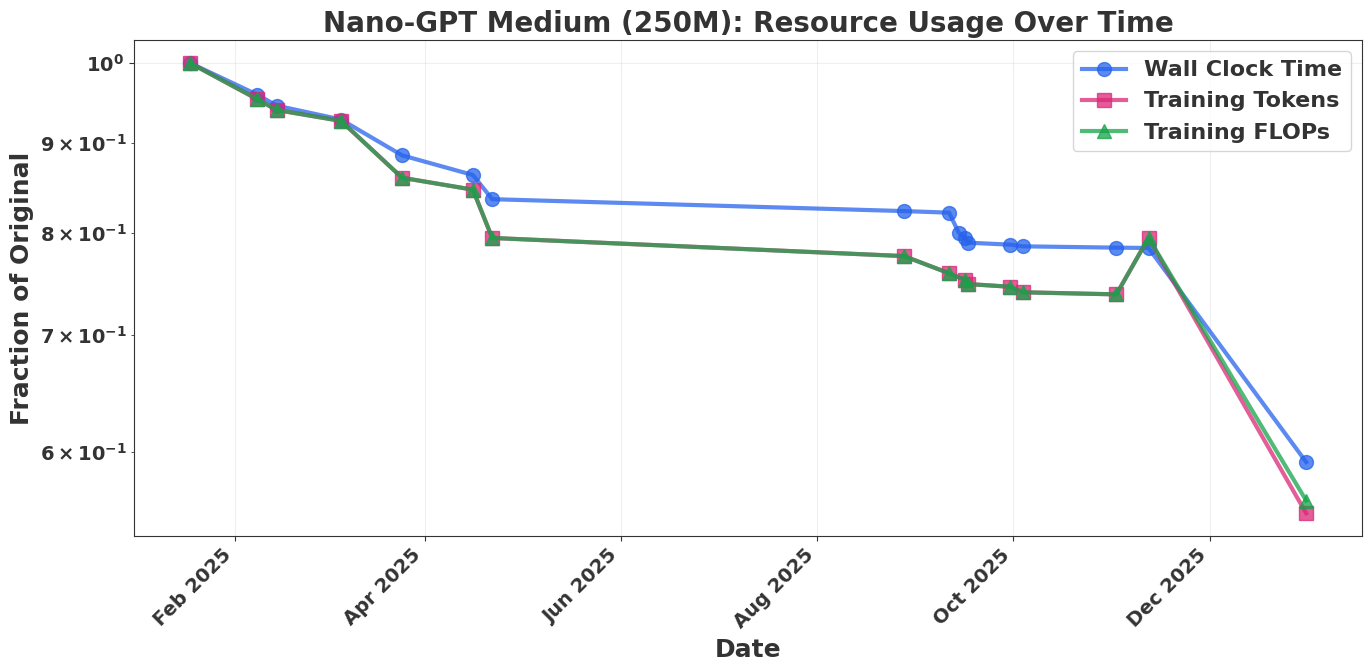

In [253]:
df_med_records = pd.read_csv("nanogpt_medium_speedrun_records.csv")
df_med_records["date"] = pd.to_datetime(df_med_records["date"])

# All series start from record 2 (iloc[1]) — the first record with complete data
baseline = df_med_records.iloc[1]
df_med_plot = df_med_records.iloc[1:].copy()
df_med_plot["time_frac"]  = df_med_plot["record_time_min"]   / baseline["record_time_min"]
df_med_plot["flop_frac"]  = df_med_plot["training_flops"]    / baseline["training_flops"]
df_med_plot["token_frac"] = df_med_plot["training_tokens_M"] / baseline["training_tokens_M"]

df_med_tokens = df_med_plot.dropna(subset=["training_tokens_M"])
df_med_flops  = df_med_plot.dropna(subset=["training_flops"])

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_med_plot["date"],   df_med_plot["time_frac"],   marker="o", markersize=10, linewidth=3, color="#2563eb", alpha=0.75, label="Wall Clock Time")
ax.plot(df_med_tokens["date"], df_med_tokens["token_frac"], marker="s", markersize=10, linewidth=3, color="#db2777", alpha=0.75, label="Training Tokens")
ax.plot(df_med_flops["date"],  df_med_flops["flop_frac"],   marker="^", markersize=10, linewidth=3, color="#16a34a", alpha=0.75, label="Training FLOPs")
ax.set_xlabel("Date", fontweight=800)
ax.set_ylabel("Fraction of Original", fontweight=800)
ax.set_title("Nano-GPT Medium (250M): Resource Usage Over Time", fontweight=800)
ax.set_yscale("log")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight(800)
ax.legend(prop={"weight": 800, "size": 16})
ax.grid(True, alpha=0.3, color="#cccccc")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig("figures/resource_usage_medium.png", dpi=150, bbox_inches="tight")
plt.show()

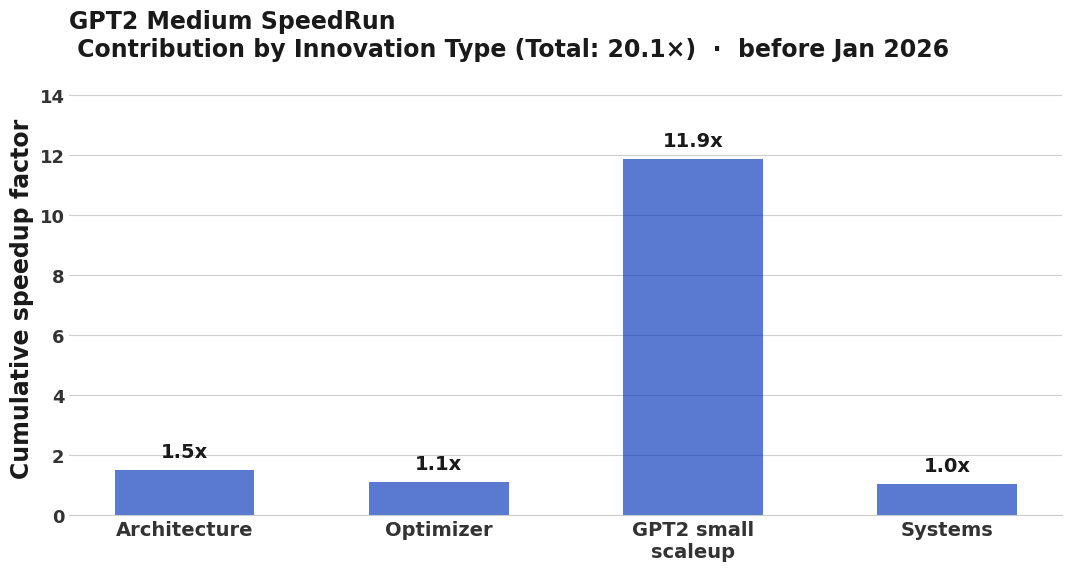


Total wall clock speedup: 20.06x  (348.0 min → 17.350 min)
  Architecture        : 1.50x  (8 records)
  Optimizer           : 1.09x  (6 records)
  Other               : 11.88x  (1 records)
  Systems             : 1.03x  (2 records)


In [254]:
# Filter by date: set cutoff_date to limit analysis (None = no filter)
cutoff_date = pd.Timestamp("2026-01-01")
df_med_analysis = df_med_records[df_med_records["date"] < cutoff_date] if cutoff_date is not None else df_med_records

med_times = df_med_analysis["record_time_min"].values
med_labels = df_med_analysis["innovation_label"].values

med_step_speedups = med_times[:-1] / med_times[1:]
med_step_labels = med_labels[1:]

categories = sorted(pd.unique(med_step_labels))
display_labels = ["GPT2 small\nscaleup" if c == "Other" else c for c in categories]
color_pool = ["#2563eb", "#16a34a", "#db2777", "#f59e0b", "#8b5cf6"]
colors = [color_pool[i % len(color_pool)] for i in range(len(categories))]

med_category_speedup = {}
for cat in categories:
    mask = med_step_labels == cat
    med_category_speedup[cat] = np.prod(med_step_speedups[mask]) if mask.any() else 1.0

med_total_speedup = np.prod(med_step_speedups)

bar_vals = [med_category_speedup[c] for c in categories]

fig, ax = plt.subplots(figsize=(11, 6))
# color="#8eb4eb"  # previous color (light cornflower blue)
bars = ax.bar(display_labels, bar_vals, color="#0033B8", alpha=0.65, edgecolor="none", width=0.55)

ax.set_ylim(0, max(bar_vals) * 1.22)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(bar_vals) * 0.025,
            f"{val:.1f}x", ha="center", va="bottom", fontsize=14, fontweight=800, color="#1a1a1a")

# Epoch-style axes: remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

ax.tick_params(axis="x", length=0, labelsize=14)
ax.tick_params(axis="y", length=0, labelsize=13)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight(800)

ax.set_ylabel("Cumulative speedup factor", fontsize=17, fontweight=800, color="#1a1a1a")

ax.grid(True, axis="y", alpha=0.95, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

title = f"GPT2 Medium SpeedRun \n Contribution by Innovation Type (Total: {med_total_speedup:.1f}×)"
if cutoff_date is not None:
    title += f"  ·  before {cutoff_date.strftime('%b %Y')}"
ax.set_title(title, fontsize=17, fontweight=800, color="#1a1a1a", loc="left", pad=18)

plt.tight_layout()
plt.savefig("figures/cumulative_speedup_medium.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal wall clock speedup: {med_total_speedup:.2f}x  ({med_times[0]:.1f} min → {med_times[-1]:.3f} min)")
for cat in categories:
    n = np.sum(med_step_labels == cat)
    print(f"  {cat:20s}: {med_category_speedup[cat]:.2f}x  ({n} records)")

## Side Calculations Done In the Paper

In [255]:
epoch_estimate = (1.92e21)/2
gpt2_cost =  43e3
gpt2_small_flop  = 7.630e+18   #estimate from claude estimate # https://github.com/karpathy/llm.c/discussions/481
gpt2_small_cost = 20
cost_per_flop_2019 = 8/(420e12)#(https://www.dataknobs.com/generativeai/tpu/tpu-gpu-cost.html?utm_source=chatgpt.com)
cost_per_flop_A100 = 2.5/(312e12) 
hardware_cost_progress = cost_per_flop_2019/cost_per_flop_A100
non_flop_factor = (gpt2_cost/gpt2_small_cost)/(hardware_cost_progress * (epoch_estimate/gpt2_small_flop))
print(f"non_flop_factor: {non_flop_factor:.2e}")





non_flop_factor: 7.19e+00


# Estimating Hardware and Data Progress GPT 2 XL 

In [256]:
#estimate base don GPT-2 large divided by 2 to keep 10 epochs instead, close to epoch's modal value and Karpathy's estimate 
epoch_estimate = (1.92e21)/2
gpt2_k_cost = 672 
gpt2_cost =  43e3
#https://github.com/karpathy/llm.c/discussions/677?utm_source=chatgpt.com

#flops estimate for trainign Karpathy's GPT2 XL model 
larg_k_flop = 6*1.6e9*33.6e9
cost_per_flop_2019 = 8/(420e12)# https://wiki.aiimpacts.org/ai_timelines/hardware_and_ai_timelines/computing_capacity_of_all_gpus_and_tpus
cost_per_flop_H100 = 3.5/(1979e12) # https://www.cisco.com/c/dam/en/us/products/collateral/servers-unified-computing/ucs-c-series-rack-servers/nvidia-h100-80-gpu.pdf and Karpathy estimate : https://github.com/karpathy/llm.c/discussions/677

data_progress = epoch_estimate/larg_k_flop

hardware_cost_progress_H100 = cost_per_flop_2019/cost_per_flop_H100
print(f"hardware_cost_progress_H100: {hardware_cost_progress_H100:.2e}")
print(f"data_progress: {data_progress:.2e}")
non_flop_factor = (gpt2_cost/gpt2_k_cost)/(hardware_cost_progress_H100 * (epoch_estimate/larg_k_flop))
print(f"non_flop_factor: {non_flop_factor:.2e}")


hardware_cost_progress_H100: 1.08e+01
data_progress: 2.98e+00
non_flop_factor: 2.00e+00


# Rate of Algorithmic Progress

In [257]:

# I don't want to get into the details of months or the inclusivness/exclusivness of years so all estimates here are year1 - year2 
origins_all_time_factor = (155)**(1/(2023-2012))
print(f"origins_all_time: {origins_all_time_factor:.2e}")

origins_2019_2023 = ((1.07)*(1.33)*(2))**(1/(2023-2019))
print(f"origins_2019_2023: {origins_2019_2023:.2e}")

# total algorihtmic progress as inferred from experiments from 2019 to 2023
origins_2019_2023_total = ((1.07)*(1.33)*(2))
print(f"origins_2019_2023_total: {origins_2019_2023_total:.2e}")


speedrun_factor = (26.26)**(1/(2026-2019))
print(f"speedrun_factor: {speedrun_factor:.2e}")

speedrun_2019_2023_inferred = speedrun_factor**(2023-2019)
print(f"speedrun_2019_2023_inferred: {speedrun_2019_2023_inferred:.2e}")

#speedrun factor with data 
speedrun_factor_data = (26.26*10)**(1/(2026-2019))
print(f"speedrun_factor_data: {speedrun_factor_data:.2e}")










origins_all_time: 1.58e+00
origins_2019_2023: 1.30e+00
origins_2019_2023_total: 2.85e+00
speedrun_factor: 1.59e+00
speedrun_2019_2023_inferred: 6.47e+00
speedrun_factor_data: 2.22e+00
